# Applied Machine Learning: Laboration 1
Aleksander Cehovin
Source also available at https://github.com/AleksanderCehovin/applied_ml_course.git


In [86]:
import tensorflow as tf
import numpy as np
# Use the local library that makes it easier to re-use code from case to case. See code for documentation
import lib.model as m
# Reload library during development to get latest changes.
from importlib import reload

### Basic Linear Model 
Run the simple baseline model for the basic linear model case

In [87]:
reload(m)
network = tf.keras.models.Sequential([
                                tf.keras.layers.Dense(units=2, input_dim=1, activation='linear'),
                                tf.keras.layers.Dense(units=1, activation='linear')
                     ])
optimizer = tf.keras.optimizers.SGD()
params = m.getDefaultParams()
print(f"Model input parameters:\n {params}")

model = m.LabModel(network, optimizer)




#Model
#model = tf.keras.models.Sequential([
#    tf.keras.layers.Dense(units=12, input_dim=1, activation='sigmoid'),
#    tf.keras.layers.Dense(units=3, activation='sigmoid'),
#    tf.keras.layers.Dense(units=1)
#])
#model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.02, beta_1 = 0.8, beta_2 = 0.9),loss='mean_squared_error')

#model = tf.keras.models.Sequential([
#    tf.keras.layers.Dense(units=10, input_dim=1, activation='sigmoid'),
#    tf.keras.layers.Dense(units=1)
#])
#model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.02, beta_1 = 0.8, beta_2 = 0.9),loss='mean_squared_error')

#model.compile(optimizer='sgd', loss='mean_squared_error')
#model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.05),loss='huber')
#model.compile(optimizer='ftrl', loss='mae')
#model.summary()

Model input parameters:
 {'train': {'X': array([-1.,  0.,  1.,  2.,  3.,  4.]), 'Y': array([-3., -1.,  1.,  3.,  5.,  7.])}, 'test': {'X': array([-3., -2., -1.,  0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9.,
       10.])}, 'loss': 'mean_squared_error', 'epocs': 50}


Model: "sequential_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_62 (Dense)                │ (None, 2)              │             4 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7 (28.00 B)

 Trainable params: 7 (28.00 B)

 Non-trainable params: 0 (0.00 B)

In [88]:
model.train()

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - loss: 10.9835
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 4.7289
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 2.1859
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 1.2271
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.8865
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.7520
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.6795
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.6257
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.5792
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.5366
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.4972
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.4605
Epoch 13/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.4264
Epoch 14/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.3947
Epoch 15/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.3652
Epoch 16/50
1/1 ━━━━━━━━━━━━━━━━

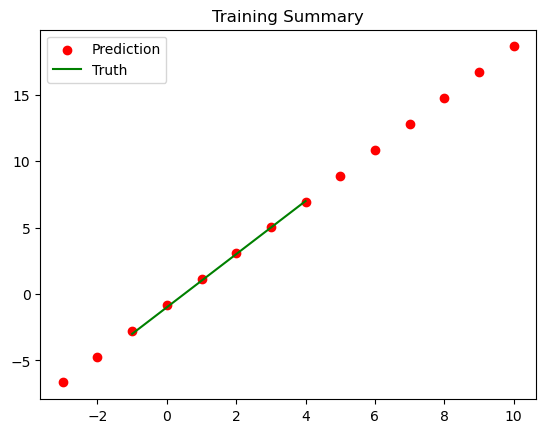

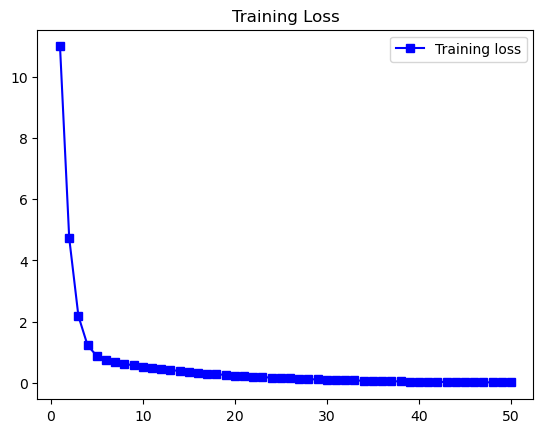

In [89]:
model.plot()

### Polynomial Curve
Next level of fitting requires non-linear activation functions, otherwise the network cannot reproduce a non-linear output.

The optimizer has been re-used from the much harder Wave case below. Likely one does not need this setting, but it works here too.

In [92]:
reload(m)
network = tf.keras.models.Sequential([
    tf.keras.layers.Dense(units=10, input_dim=1, activation='sigmoid'),
    tf.keras.layers.Dense(units=1)
])
optimizer=tf.keras.optimizers.Adam(learning_rate=0.02, beta_1 = 0.8, beta_2 = 0.9)

params = m.getDefaultParams()
params["train"]["X"]= np.array([-3.0, -2.0, -1.0,  0.0, 1.0, 2.0, 3.0, 4.0])
params["train"]["Y"]= np.array([-37.0, -10.0, -1.0, 2.0, -1.0, -2.0, 5.0, 26.0])
params["epocs"]=600
print(f"Model input parameters:\n {params}")

model = m.LabModel(network, optimizer, params)

Model input parameters:
 {'train': {'X': array([-3., -2., -1.,  0.,  1.,  2.,  3.,  4.]), 'Y': array([-37., -10.,  -1.,   2.,  -1.,  -2.,   5.,  26.])}, 'test': {'X': array([-3., -2., -1.,  0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9.,
       10.])}, 'loss': 'mean_squared_error', 'epocs': 600}


Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_66 (Dense)                │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

In [93]:
model.train()

Epoch 1/600
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 508ms/step - loss: 279.9209
Epoch 2/600
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 277.7661
Epoch 3/600
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 275.6082
Epoch 4/600
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 273.4516
Epoch 5/600
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 271.3011
Epoch 6/600
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 269.1607
Epoch 7/600
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 267.0339
Epoch 8/600
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 264.9227
Epoch 9/600
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 262.8275
Epoch 10/600
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 260.7487
Epoch 11/600
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 258.6876
Epoch 12/600
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 256.6468
Epoch 13/600
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 254.6291
Epoch 14/600
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 252.6377
Epoch 15/600
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - los

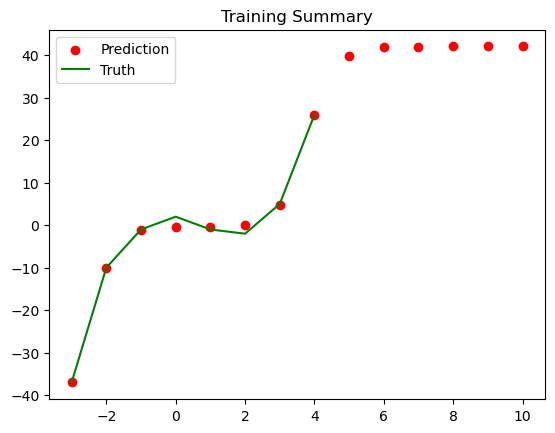

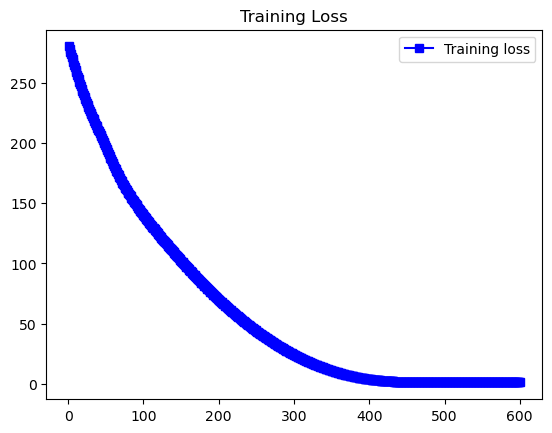

In [94]:
model.plot()

### Final Wave Function
This function was the hardest to train, it required more epocs to converge and an additional hidden layer. Sometimes it does not converge completely and some part of the function is not fitted as well. This function was the reason I started to experiment with another optimizer an its mixing parameters, in order to find a solution faster and not get stuck in a local minimum that generated very bad fitting.

In [95]:
reload(m)
network = tf.keras.models.Sequential([
    tf.keras.layers.Dense(units=12, input_dim=1, activation='sigmoid'),
    tf.keras.layers.Dense(units=3, activation='sigmoid'),
    tf.keras.layers.Dense(units=1)
])
optimizer =tf.keras.optimizers.Adam(learning_rate=0.02, beta_1 = 0.8, beta_2 = 0.9)

params = m.getDefaultParams()
params["train"]["X"] = np.array([1, 2, 3,  4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20])
params["train"]["Y"] = np.array([1, 0.8, 0.3, -0.3, -0.8, -1, -0.8, -0.3, 0.3, 0.8, 1, 0.8, 0.3, -0.3, -0.8, -1, -0.8, -0.3, 0.3, 0.8])
params["test"]["X"] = np.array([0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 13.0, 16.0, 19.0, 22.0])
params["epocs"]=1250
print(f"Model input parameters:\n {params}")

model = m.LabModel(network, optimizer, params)

Model input parameters:
 {'train': {'X': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20]), 'Y': array([ 1. ,  0.8,  0.3, -0.3, -0.8, -1. , -0.8, -0.3,  0.3,  0.8,  1. ,
        0.8,  0.3, -0.3, -0.8, -1. , -0.8, -0.3,  0.3,  0.8])}, 'test': {'X': array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 13., 16.,
       19., 22.])}, 'loss': 'mean_squared_error', 'epocs': 1250}


Model: "sequential_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_68 (Dense)                │ (None, 12)             │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 3)              │            39 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67 (268.00 B)

 Trainable params: 67 (268.00 B)

 Non-trainable params: 0 (0.00 B)

In [96]:
model.train()

Epoch 1/1250
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 813ms/step - loss: 0.4965
Epoch 2/1250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.4835
Epoch 3/1250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.4851
Epoch 4/1250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.4815
Epoch 5/1250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.4757
Epoch 6/1250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.4725
Epoch 7/1250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.4712
Epoch 8/1250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.4686
Epoch 9/1250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.4649
Epoch 10/1250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.4618
Epoch 11/1250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.4598
Epoch 12/1250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.4574
Epoch 13/1250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.4545
Epoch 14/1250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.4518
Epoch 15/1250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.4496
Epo

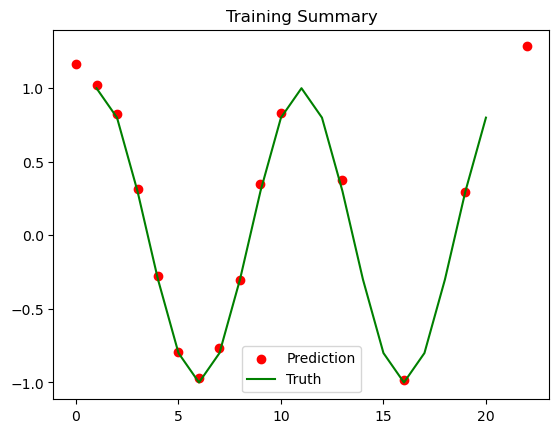

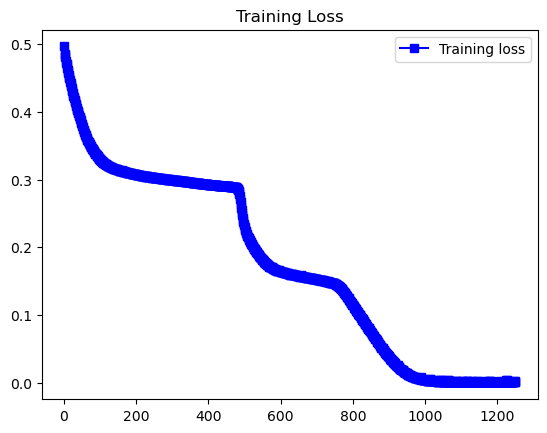

In [97]:
model.plot()